In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2026-04-19 15:41:17.763017: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 15:41:17.814855: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-19 15:41:21.203657: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from MIMICUtil import *
from sklearn.decomposition import PCA

In [4]:
columns = [
    'output_first_height',
    'chart_first_height_(cm)',
    'chart_first_admission_weight_(kg)',
    'chart_first_admission_weight_(lbs.)',
    'chart_first_daily_weight',

    'chart_first_heart_rate',
    'chart_first_o2_saturation_pulseoxymetry',
    'chart_first_temperature_celsius',
    'chart_first_respiratory_rate',
    'chart_first_inspired_o2_fraction',

    'chart_first_non_invasive_blood_pressure_systolic',
    'chart_first_non_invasive_blood_pressure_diastolic',
    'chart_first_non_invasive_blood_pressure_mean',
    'chart_first_art_bp_systolic',
    'chart_first_art_bp_diastolic',
    'chart_first_art_bp_mean',
    'chart_first_arterial_blood_pressure_systolic',
    'chart_first_arterial_blood_pressure_diastolic',
    'chart_first_arterial_blood_pressure_mean',

    'chart_first_ph_(arterial)',
    'chart_first_arterial_o2_pressure',
    'chart_first_arterial_co2_pressure',
    'chart_first_tco2_(calc)_arterial',
    'chart_first_arterial_base_excess',
    'chart_first_lactic_acid',

    'chart_first_qtc',

    'chart_first_wbc',
    'chart_first_hemoglobin',
    'chart_first_hematocrit_(serum)',

    'chart_first_sodium_(serum)',
    'chart_first_chloride_(serum)',
    'chart_first_bun',
    'chart_first_creatinine_(serum)',
    'chart_first_glucose_(serum)',
    'chart_first_calcium_non-ionized',
    'chart_first_ionized_calcium',
    'chart_first_magnesium',
    'chart_first_phosphorous',

    'chart_first_total_bilirubin',
    'chart_first_direct_bilirubin',
    'chart_first_total_protein',
    'chart_first_ck_(cpk)',
    'chart_first_ck-mb_fraction_(%)',
    'chart_first_ldh',
    'chart_first_triglyceride',
    'chart_first_cholesterol',
    'chart_first_hdl',
    'chart_first_ldl_calculated',

    'chart_first_d-dimer',
    'lab_first_inr',
    'lab_first_prothrombin_time',
    'lab_first_ptt',
    'lab_first_fibrinogen',
    'lab_first_c_reactive_protein_(crp)',
    'lab_first_troponin-t',
    'lab_first_specific_gravity_(urine)',
    'first_mGCS',
    'hypothermia',
     'long_title_atrial_fibrillation',
       'long_title_chronic_atrial_fibrillation',
       'long_title_chronic_atrial_fibrillation,_unspecified',
       'long_title_other_persistent_atrial_fibrillation',
       'long_title_paroxysmal_atrial_fibrillation',
       'long_title_persistent_atrial_fibrillation',
       'long_title_unspecified_atrial_fibrillation',
       'long_title_ventricular_fibrillation'
    'other_underlying_condition',
    'underlying_cardiac_condition',
    'following_other_sur',
    'following_cardiac_sur',
    'subject_id', 'time', 'time_date', 'event_id', 'matched_chartdate',
       'bmi', 'height_in', 'weight_lbs', 'height_cm', 'weight_kg'
]


In [5]:
import re
import pandas as pd
from difflib import get_close_matches

def normalize_col(s):
    s = str(s).lower()
    s = s.replace('%', ' percent ')
    s = s.replace('o2', 'oxygen')
    s = s.replace('fio2', 'fraction inspired oxygen')
    s = s.replace('bp', 'blood pressure')
    s = s.replace('hr', 'heart rate')
    s = s.replace('wbc', 'white blood cell')
    s = s.replace('hgb', 'hemoglobin')
    s = s.replace('bun', 'blood urea nitrogen')
    s = s.replace('gcs', 'glasgow coma scale')
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s
concept_map = {
    'patient_id': ['patientunitstayid', 'subject_id', 'stay_id', 'patient id', 'unit stay id'],
    'gender': ['gender', 'sex'],
    'age': ['age', 'anchor_age'],
    'bmi': ['bmi', 'body mass index'],

    'sbp': ['non invasive bp systolic', 'systolic blood pressure', 'sbp'],
    'dbp': ['non invasive bp diastolic', 'diastolic blood pressure', 'dbp'],
    'map': ['non invasive bp mean', 'mean arterial pressure', 'map'],

    'heart_rate': ['heart rate', 'hr', 'pulse'],
    'spo2': ['o2 saturation', 'oxygen saturation', 'spo2', 'sao2'],
    'temperature_c': ['temperature c', 'temp c', 'temperature'],
    'resp_rate': ['respiratory rate', 'resp rate', 'rr'],
    'fio2': ['fio2', 'fraction inspired oxygen'],
    'gcs_total': ['gcs total', 'glasgow coma scale total', 'firstgcs'],
    'gcs_motor': ['motor', 'gcs motor', 'glasgow motor'],
    'qtc': ['qtc', 'qt corrected'],

    'ph': ['ph'],
    'pao2': ['pao2', 'pao2 arterial', 'arterial po2'],
    'paco2': ['paco2', 'arterial pco2'],
    'bicarbonate': ['bicarbonate', 'hco3'],
    'lactate': ['lactate'],
    'wbc': ['wbc', 'white blood cell'],
    'hemoglobin': ['hgb', 'hemoglobin'],
    'platelets': ['platelets', 'platelet count'],
    'sodium': ['sodium', 'na'],
    'potassium': ['potassium', 'k'],
    'bun': ['bun', 'blood urea nitrogen'],
    'creatinine': ['creatinine'],
    'calcium': ['calcium'],
    'magnesium': ['magnesium', 'mg'],
    'glucose': ['glucose'],
    'troponin_i': ['troponin i'],
    'troponin_t': ['troponin t'],

    'vf': ['ventricular fibrillation', 'vf', 'initial rhythm ventricular fibrillation'],
    'vt': ['ventricular tachycardia', 'vt', 'initial rhythm ventricular tachycardia'],
    'pea': ['pulseless electrical activity', 'pea', 'initial rhythm pulseless electrical activity'],
    'asystole': ['asystole', 'initial rhythm asystole'],

    'hypothermia': ['hypothermia', 'targeted temperature management', 'ttm']
}

from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

def find_candidate_columns(target_aliases, columns, top_n=10):
    norm_cols = {col: normalize_col(col) for col in columns}
    scores = []

    for col, norm_col in norm_cols.items():
        best_score = 0
        best_alias = None

        for alias in target_aliases:
            norm_alias = normalize_col(alias)

            # exact or substring boosts
            score = similarity(norm_alias, norm_col)
            if norm_alias == norm_col:
                score += 1.0
            elif norm_alias in norm_col or norm_col in norm_alias:
                score += 0.35

            if score > best_score:
                best_score = score
                best_alias = alias

        scores.append((col, norm_col, best_alias, best_score))

    scores = sorted(scores, key=lambda x: x[3], reverse=True)
    return pd.DataFrame(scores[:top_n], columns=['column', 'normalized', 'matched_alias', 'score'])

In [6]:
new_cols = myPredictorsDf.columns.tolist()

for concept, aliases in concept_map.items():
    print(f"\n### {concept}")
    display(find_candidate_columns(aliases, new_cols, top_n=5))

NameError: name 'myPredictorsDf' is not defined

In [93]:
matches = []

for concept, aliases in concept_map.items():
    cand = find_candidate_columns(aliases, myPredictorsDf.columns, top_n=2)
    row = cand.iloc[0]
    matches.append({
        'concept': concept,
        'best_column': row['column'],
        'matched_alias': row['matched_alias'],
        'score': row['score']
    })
    row = cand.iloc[1]
    matches.append({
        'concept': concept,
        'best_column': row['column'],
        'matched_alias': row['matched_alias'],
        'score': row['score']
    })

match_df = pd.DataFrame(matches).sort_values('score', ascending=False)
match_df

,concept,best_column,matched_alias,score
0,patient_id,subject_id,subject_id,2.000000
2,gender,gender,gender,2.000000
4,age,age,age,2.000000
72,hypothermia,hypothermia,hypothermia,2.000000
10,dbp,chart_max_non_invasive_blood_pressure_diastolic,non invasive bp diastolic,1.230952
...,...,...,...,...
1,patient_id,chart_icu_consent_signed,patient id,0.529412
65,vf,chart_min_temporary_ventricular_stim_setting_ma,initial rhythm ventricular fibrillation,0.511628
70,asystole,chart_heart_rhythm_V Paced,initial rhythm asystole,0.489796
71,asystole,chart_last_assisted_systole,initial rhythm asystole,0.480000


In [346]:
import re
import pandas as pd
from difflib import SequenceMatcher

# ---------------------------------------------------
# 1) all pasted columns as targets
# ---------------------------------------------------
target_columns = [
    'SUBJID',
    'groupe',
    'CPC_SC3',
    'J0_SEX',
    'J0_TAILLE',
    'J0_POIDS',
    'J0_BMI',
    'J0_AGE',
    'J0_PAS',
    'J0_PAD',
    'J0_PAM',
    'J0_FC',
    'J0_SPO2',
    'J0_GLASGOW',
    'J0_GLASGOW_CONTROLE',
    'J0_OCULAIRE',
    'J0_VERBALE',
    'J0_MOTRICE',
    'J0_PUPILG',
    'J0_PUPILG_REA',
    'J0_PUPILD',
    'J0_PUPILD_REA',
    'J0_CILIAIRE',
    'J0_CORNEEN',
    'J0_REFLEXVEST',
    'J0_REFLEXCEPH',
    'J0_REFLEXCARD',
    'J0_TEMP',
    'J0_IGSII',
    'J0_MCCABE',
    'J0_KNAUS',
    'J0_CHARLSON1',
    'J0_CHARLSON2',
    'J0_CHARLSON3',
    'J0_CHARLSON4',
    'J0_CHARLSON5',
    'J0_CHARLSON6',
    'J0_CHARLSON7',
    'J0_CHARLSON8',
    'J0_CHARLSON9',
    'J0_CHARLSON10',
    'J0_CHARLSON11',
    'J0_CHARLSON12',
    'J0_CHARLSON13',
    'J0_CHARLSON14',
    'V0_CHARLSON15',
    'V0_CHARLSON16',
    'V0_CHARLSON17',
    'V0_CHARLSON18',
    'V0_CHARLSON18B',
    'V0_CHARLSON19',
    'J0_CHARLSON',
    'J0_ATCD',
    'J0_CARDIO',
    'J0_NYHA',
    'J0_MYOCARD',
    'J0_ARTERIO',
    'J0_HTA',
    'J0_POUMON',
    'J0_IRC',
    'J0_HYPERCAP',
    'J0_O2',
    'J0_TABAC',
    'J0_RYTHM',
    'J0_CAUSE2_ACR',
    'J0_DSA',
    'J0_DSA_P',
    'J0_TEMOIN',
    'J0_TEMOIN_MASSE',
    'J0_LIEU_ACR',
    'J0_NOFLOW',
    'J0_LOWFLOW',
    'J0_ADRE',
    'J0_ADRE_DOS',
    'J0_CORDA',
    'J0_CORDA_DOS',
    'J0_BICARB',
    'J0_BICARB_DOS',
    'V0_REFROIDI',
    'V0_CHOC_AV',
    'V0_CHOC_AP',
    'V0_PLANCHE',
    'V0_THROMBO',
    'V0_CORO_ACR',
    'V0_ANGIO_ACR',
    'V0_ANGIO_YES',
    'V0_BALLON',
    'V0_ACR2',
    'J0_CURAR',
    'J0_SEDATIF',
    'J0_MORPHIN',
    'J0_COAGUL',
    'J0_AGREG',
    'J0_ANTIBIO',
    'J0_AMINE',
    'J0_NORA',
    'J0_ADRE2',
    'J0_DOBU',
    'J0_DOPA',
    'J0_PEP',
    'J0_FIO2',
    'J0_VT',
    'J0_FR',
    'BIO_LEUCO',
    'BIO_HEMO',
    'BIO_PLAQ',
    'BIO_TP',
    'BIO_DDIMERE',
    'BIO_SODIUM',
    'BIO_POTAS',
    'BIO_UREE',
    'BIO_CREAT',
    'BIO_CALCIUM',
    'BIO_MAGNE',
    'BIO_GLYCEMI',
    'BIO_PROTID',
    'BIO_LIPAS',
    'BIO_TROPO',
    'BIO_TEMP',
    'BIO_FIO2',
    'BIO_PH',
    'BIO_PAO2',
    'BIO_PACO2',
    'BIO_BICARB',
    'BIO_LACTAT',
    'BIO_TROPO2',
    'BIO_TROPO_CGT',
    'ECG',
    'ECG_QTC',
    'ECG_ANOMALI',
    'ECG_SUS_ST',
    'ECG_SOUS_ST',
    'ECG_BAVI',
    'ECG_BAVII',
    'ECG_BAVIII',
    'ECG_BBG',
    'ECG_BBD',
    'ECG_TACHICARD',
    'ECG_FIBRIL',
    'ECG_SALV_VENT',
    'ECG_FLUTER',
    'ECG_SALV_SUPRA',
    'SOFA_SC',
    'SOFA_RESPIR',
    'SOFA_CARDIO',
    'SOFA_COAG',
    'SOFA_NEURO',
    'SOFA_FOIE',
    'SOFA_RENAL',
    'EI_EI',
    'EI_HEMOSEVER',
    'EI_TRANSFUS',
    'EI_INTRACER',
    'EI_CHIR',
    'EI_EXTRARENAL',
    'EI_OAP',
    'EI_ECHO',
    'EI_DIURETIQ',
    'EI_CONVULS',
    'EI_ARYTHMI',
    'EI_ANTIEPILEPTIQ',
    'BARTHEL_SC',
    'SOFA_SC7',
    'SOFA_SC1',
    'DS_DC',
    'DAYS_ALIVE_30',
    'CPC12',
    'SEX'
]

# ---------------------------------------------------
# 2) normalize names for better matching
# ---------------------------------------------------
def normalize_col(s: str) -> str:
    s = str(s).lower().replace('_', ' ')

    replacements = {
        'subjid': 'subject patient id',
        'groupe': 'group treatment arm',
        'taille': 'height',
        'poids': 'weight',
        'bmi': 'body mass index',
        'age': 'age',
        'pas': 'systolic blood pressure sbp',
        'pad': 'diastolic blood pressure dbp',
        'pam': 'mean arterial pressure map',
        'fc': 'heart rate pulse',
        'spo2': 'oxygen saturation spo2',
        'glasgow': 'glasgow coma scale gcs',
        'oculaire': 'eye ocular',
        'verbale': 'verbal',
        'motrice': 'motor',
        'pupilg': 'left pupil',
        'pupild': 'right pupil',
        'rea': 'reactive reactivity',
        'ciliaire': 'ciliary reflex',
        'corneen': 'corneal reflex',
        'reflexvest': 'vestibular reflex',
        'reflexceph': 'cephalic reflex',
        'reflexcard': 'cardiac reflex',
        'igsii': 'saps ii severity score',
        'mccabe': 'mccabe score',
        'knaus': 'knaus apache chronic health',
        'atcd': 'past medical history comorbidity',
        'cardio': 'cardiovascular history',
        'nyha': 'nyha heart failure class',
        'myocard': 'myocardial infarction',
        'arterio': 'peripheral arterial disease vascular disease',
        'hta': 'hypertension',
        'poumon': 'lung pulmonary disease',
        'irc': 'chronic kidney disease renal insufficiency',
        'hypercap': 'hypercapnia',
        'o2': 'oxygen therapy oxygen',
        'tabac': 'smoking tobacco',
        'rythm': 'rhythm arrest rhythm',
        'cause2 acr': 'cardiac arrest cause',
        'dsa': 'defibrillation shock',
        'temoin': 'witnessed witnessed arrest',
        'lieu acr': 'cardiac arrest location',
        'noflow': 'no flow',
        'lowflow': 'low flow',
        'adre': 'epinephrine adrenaline',
        'corda': 'cordarone amiodarone',
        'bicarb': 'bicarbonate',
        'refroidi': 'cooling hypothermia targeted temperature management ttm',
        'choc': 'shock',
        'planch': 'board',
        'thrombo': 'thrombolysis thrombosis',
        'coro acr': 'coronary angiography arrest',
        'angio': 'angiography',
        'ballon': 'balloon pump',
        'curar': 'neuromuscular blocker paralysis',
        'sedatif': 'sedation sedative',
        'morphin': 'morphine opioid',
        'coagul': 'anticoagulation coagulopathy',
        'agreg': 'antiplatelet aggregation',
        'antibio': 'antibiotic',
        'amine': 'vasopressor amine',
        'nora': 'norepinephrine noradrenaline',
        'dobu': 'dobutamine',
        'dopa': 'dopamine',
        'pep': 'peep positive end expiratory pressure',
        'fio2': 'fraction inspired oxygen fio2',
        'vt': 'tidal volume vt ventricular tachycardia',
        'fr': 'respiratory rate',
        'leuco': 'white blood cell wbc leukocyte',
        'hemo': 'hemoglobin hgb',
        'plaq': 'platelets platelet count',
        'tp': 'prothrombin time pt',
        'ddimere': 'd dimer',
        'uree': 'urea bun blood urea nitrogen',
        'creat': 'creatinine',
        'magne': 'magnesium',
        'glycemi': 'glucose glycemia',
        'protid': 'protein total protein',
        'lipas': 'lipase',
        'tropo': 'troponin',
        'ph': 'ph',
        'pao2': 'arterial oxygen pao2',
        'paco2': 'arterial carbon dioxide paco2',
        'lactat': 'lactate',
        'qtc': 'qt corrected qtc',
        'anomali': 'abnormality',
        'sus st': 'st elevation',
        'sous st': 'st depression',
        'bavi': 'av block first degree',
        'bavii': 'av block second degree',
        'baviii': 'av block third degree',
        'bbg': 'left bundle branch block',
        'bbd': 'right bundle branch block',
        'tachicard': 'tachycardia',
        'fibril': 'fibrillation',
        'salv vent': 'ventricular tachycardia ventricular run',
        'fluter': 'flutter',
        'salv supra': 'supraventricular run',
        'respir': 'respiratory',
        'cardio': 'cardiovascular cardiac',
        'coag': 'coagulation',
        'neuro': 'neurologic neurological',
        'foie': 'liver hepatic',
        'renal': 'renal kidney',
        'hemosever': 'severe bleeding hemorrhage',
        'transfus': 'transfusion',
        'intracer': 'intracerebral intracranial',
        'chir': 'surgery surgical',
        'oap': 'pulmonary edema',
        'echo': 'echocardiography echo',
        'diuretiq': 'diuretic',
        'convuls': 'seizure convulsion',
        'arythmi': 'arrhythmia',
        'antiepileptiq': 'antiepileptic',
        'barthel': 'barthel functional status',
        'dc': 'death deceased',
        'days alive 30': 'days alive at 30 days',
        'cpc': 'cerebral performance category'
    }

    for old, new in replacements.items():
        s = s.replace(old, new)

    s = re.sub(r'[^a-z0-9]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()

# ---------------------------------------------------
# 3) score each target against all columns in df_other
# ---------------------------------------------------
def score_target_against_columns(target_col, candidate_columns, top_n=2):
    norm_target = normalize_col(target_col)
    target_tokens = set(norm_target.split())

    rows = []
    for col in candidate_columns:
        norm_col = normalize_col(col)
        col_tokens = set(norm_col.split())

        score = similarity(norm_target, norm_col)

        if norm_target == norm_col:
            score += 1.0
        elif norm_target in norm_col or norm_col in norm_target:
            score += 0.35

        if len(target_tokens) > 0:
            overlap = len(target_tokens & col_tokens) / len(target_tokens)
            score += 0.5 * overlap

        rows.append({
            'target_column': target_col,
            'candidate_column': col,
            'score': score
        })

    return pd.DataFrame(rows).sort_values('score', ascending=False).head(top_n)

def search_all_target_columns(df_other, target_columns=target_columns, top_n=2):
    results = []
    for target in target_columns:
        results.append(score_target_against_columns(target, df_other.columns, top_n=top_n))
    return pd.concat(results, ignore_index=True)

# ---------------------------------------------------
# 4) run it
# ---------------------------------------------------
# replace df_other with your other dataset
columns2 = [x for x in myPredictorsDf.columns if '_min_' not in x.lower() and '_max_' not in x.lower() and '_last_' not in x.lower() and '_mean_' not in x.lower()]
top2_matches = search_all_target_columns(myPredictorsDf[columns2], target_columns=target_columns, top_n=2)

# tidy output
top2_matches = top2_matches.sort_values(['target_column', 'score'], ascending=[True, False]).reset_index(drop=True)
top2_matches

,target_column,candidate_column,score
0,BARTHEL_SC,chart_seizure_duration_Status,0.721491
1,BARTHEL_SC,chart_cervical_collar_status_On,0.701271
2,BIO_BICARB,med_sodium_bicarbonate,0.619048
3,BIO_BICARB,input_sodium_bicarbonate_8.4%,0.583333
4,BIO_CALCIUM,med_calcium_acetate,0.783333
...,...,...,...
331,V0_REFROIDI,chart_impaired_tissue_perfusion_ncp_-_interven...,0.607646
332,V0_THROMBO,chart_stool_consistency_Loose,0.436364
333,V0_THROMBO,lab_first_prothrombin_time,0.423077
334,groupe,chart_incision_#1-_treatment_Ace Wrap,0.970930


In [347]:
columns = top2_matches.candidate_column.tolist()

In [348]:
[x for x in myPredictorsDf.columns if 'bmi' in x]

[]

In [349]:
[x for x in myPredictorsDf.columns if 'long_title' in x.lower()]

[]

In [ ]:
columns += ['hypothermia', 'bmi', 'height_cm', 'weight_kg', 'first_mGCS', 'long_title_atrial_fibrillation',
 'long_title_chronic_atrial_fibrillation',
 'long_title_paroxysmal_atrial_fibrillation',
 'long_title_unspecified_atrial_fibrillation',
 'long_title_ventricular_fibrillation']

In [9]:
columns = columns = ['chart_seizure_duration_Status',
 'chart_cervical_collar_status_On',
 'med_sodium_bicarbonate',
 'input_sodium_bicarbonate_8.4%',
 'med_calcium_acetate',
 'input_calcium_gluconate',
 'med_miconazole_2%_cream',
 'chart_first_creatinine_(serum)',
 'chart_first_d-dimer',
 'output_first_d-dimer',
 'chart_first_fio2_(ch)',
 'chart_first_fio2_(ecmo)',
 'chart_first_glucose_(serum)',
 'chart_first_glucose_(whole_blood)',
 'chart_first_hemoglobin',
 'chart_problem_list_.H/O anemia, hemolytic',
 'med_calcium_acetate',
 'input_po_intake',
 'input_packed_red_blood_cells',
 'chart_first_hematocrit_(whole_blood_-_calc)',
 'chart_first_lipase',
 'output_first_lipase',
 'chart_first_magnesium',
 'input_magnesium_sulfate',
 'chart_first_peco2',
 'chart_first_etco2',
 'chart_first_peco2',
 'chart_first_svo2',
 'chart_first_gi_ph',
 'chart_first_ph_(venous)',
 'lab_first_platelet_count',
 'chart_first_absolute_count_-_eos',
 'input_po_intake',
 'lab_first_potassium_(serum)',
 'chart_first_total_protein',
 'output_first_total_protein',
 'input_heparin_sodium',
 'med_nitroprusside_sodium',
 'chart_lle_temp_Warm',
 'chart_rue_temp_Cold',
 'lab_first_prothrombin_time',
 'output_first_alt',
 'lab_first_troponin-t',
 'input_rocuronium',
 'chart_first_svo2',
 'chart_first_peco2',
 'lab_first_troponin-t',
 'input_tirofiban_(aggrastat)',
 'chart_first_arterial_blood_pressure_alarm_-_high',
 'chart_first_arterial_blood_pressure_mean',
 'chart_performance_level_Auto',
 'chart_performance_level_P2',
 'chart_performance_level_(r)_P6',
 'chart_performance_level_Auto',
 'chart_daily_wake_up_No, at goal RASS',
 'death_at_disch',
 'death_at_disch',
 'med_oxycodone_(immediate_release)_',
 'age',
 'subject_id',
 'chart_speech_Normal',
 'chart_lue_color_Normal',
 'chart_heart_rhythm_2nd AV M2 (Second degree AV Block - Mobitz 2) ',
 'lab_first_ldl_measured',
 'lab_first_digoxin',
 'lab_first_ldl_measured',
 'lab_first_digoxin',
 'lab_first_ldl_measured',
 'chart_heart_rhythm_3rd AV (Complete Heart Block) ',
 'chart_art_bubble_on_(ch)',
 'chart_urine_appearance_Cloudy',
 'chart_art_bubble_on_(ch)',
 'med_sarna_lotion',
 'chart_first_impella_catheter_position',
 'chart_lue_temp_Warm',
 'med_fentanyl_citrate',
 'chart_first_qtc',
 'output_first_qtc',
 'chart_temporary_ventricular_sens_Yes',
 'chart_temporary_ventricular_capture_Yes',
 'chart_problem_list_Ventricular tachycardia, sustained',
 'chart_first_vd/vt_ratio',
 'med_vasopressin',
 'chart_st_segment_monitoring_on',
 'chart_st_segment_monitoring_on',
 'med_sarna_lotion',
 'chart_problem_list_Tachycardia, Other',
 'chart_heart_rhythm_ST (Sinus Tachycardia) ',
 'med_alteplase',
 'med_norepinephrine',
 'chart_heart_rhythm_V Paced',
 'chart_problem_list_Cardiac arrest',
 'chart_post-op_care_ncp_-_interventions_Assess surgical wounds and drains',
 'med_ursodiol',
 'chart_seizure_duration_Status',
 'med_sarna_lotion',
 'input_diltiazem',
 'chart_skin_condition_Diaphoretic',
 'chart_angio_site_#_1_R Femoral',
 'chart_first_ph_(venous)',
 'med_linezolid',
 'med_aspirin_ec',
 'med_sarna_lotion',
 'chart_impaired_fluid_balance_ncp_-_interventions_Monitoring electrolytes / renal function',
 'chart_first_hemoglobin',
 'chart_stroke_ncp_-_type_Hemorrhagic',
 'chart_first_intra_cranial_pressure',
 'chart_first_intra_cranial_pressure_#2',
 'chart_problem_list_Pulmonary edema',
 'chart_first_pulmonary_artery_pressure_mean',
 'med_tamsulosin',
 'med_insulin',
 'med_epinephrine_1:1000',
 'med_epinephrine',
 'med_epinephrine_1:1000',
 'med_epinephrine',
 'med_epinephrine_1:1000',
 'med_epinephrine',
 'age',
 'gender',
 'lab_first_platelet_count',
 'chart_pain_management_Repositioned',
 'med_vasopressin',
 'input_vasopressin',
 'med_sarna_lotion',
 'med_mannitol',
 'chart_first_arterial_blood_pressure_alarm_-_high',
 'chart_problem_list_Cerebrovascular disease, other',
 'chart_past_medical_history_COPD',
 'chart_cv_-_past_medical_history_CAD',
 'med_sodium_bicarbonate',
 'input_sodium_bicarbonate_8.4%',
 'med_sodium_bicarbonate',
 'input_sodium_bicarbonate_8.4%',
 'chart_first_bis_index_range',
 'chart_first_cardiac_index_(ci_nicom)',
 'chart_education_topic_Cardioversion',
 'chart_problem_list_Shock, cardiogenic',
 'chart_problem_list_Cardiac arrest',
 'chart_cardiac_assist_cannula_site_appear_WNL',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_gag_reflex_Intact',
 'chart_gag_reflex_Absent',
 'chart_incision_#1-_location_Tracheostomy',
 'chart_incision_#1-_location_Chin',
 'med_amiodarone',
 'input_amiodarone',
 'med_amiodarone',
 'input_amiodarone',
 'chart_corneal_reflex_left_Intact',
 'chart_corneal_reflex_left_Absent',
 'chart_daily_wake_up_deferred_Neuromusc Block',
 'chart_neuro_drain_#1_level_15 cm',
 'input_lidocaine',
 'input_amiodarone',
 'input_lidocaine',
 'med_midodrine',
 'chart_heart_rhythm_AF (Atrial Fibrillation)',
 'chart_problem_list_.H/O atrial fibrillation (Afib)',
 'chart_heart_rhythm_AF (Atrial Fibrillation)',
 'chart_problem_list_.H/O atrial fibrillation (Afib)',
 'med_nafcillin',
 'chart_first_heart_rate',
 'chart_first_fio2_(ch)',
 'chart_first_fio2_(ecmo)',
 'chart_first_respiratory_rate',
 'chart_first_respiratory_rate_(set)',
 'chart_20_g_infiltration_scale_Grade 0',
 'chart_20_g_infiltration_scale_Grade 2',
 'chart_goal_richmond-ras_scale_ No eye contact',
 'chart_20_g_infiltration_scale_Grade 0',
 'chart_cv_-_past_medical_history_Hypertension',
 'chart_problem_list_.H/O abdominal compartment syndrome / Intraabdominal Hypertension (IAH, ACS)',
 'hypothermia',
 'med_nephrocaps',
 'chart_pain_level_Unable to Score',
 'chart_pain_level_response_Unable to Score',
 'chart_circuit_configuration_(ch)_VA',
 'chart_par-circulation_BP +/- 20% of pre-anesthesthetic level',
 'chart_is_the_spokesperson_the_health_care_proxy',
 'chart_20_gauge_placed_in_the_field',
 'chart_problem_list_Cardiac arrest',
 'chart_ett_location_Oral-R',
 'chart_first_blood_flow_(ml/min)',
 'chart_first_flow_(ch)',
 'chart_pain_level_Unable to Score',
 'chart_pain_level_response_Unable to Score',
 'med_morphine_infusion_–_comfort_care_guidelines',
 'med_norepinephrine',
 'chart_motor_l_leg_Localizes',
 'chart_motor_l_arm_Localizes',
 'chart_problem_list_Myocardial infarction, acute (AMI, STEMI, NSTEMI)',
 'underlying_cardiac_condition',
 'chart_first_flow_(ch)',
 'chart_first_flow_(ecmo)',
 'med_norepinephrine',
 'input_norepinephrine',
 'chart_first_heart_rate_alarm_-_low',
 'chart_first_heart_rate_alarm_-_high',
 'chart_svo2_sqi_1',
 'chart_first_svo2',
 'chart_eye_care',
 'chart_gcs_-_eye_opening_To Pain',
 'chart_first_lipase',
 'chart_first_manual_blood_pressure_diastolic_left',
 'input_diazepam_(valium)',
 'input_lorazepam_(ativan)',
 'chart_first_lipase',
 'chart_past_medical_history_COPD',
 'input_famotidine_(pepcid)',
 'lab_first_brain_natiuretic_peptide_(bnp)',
 'chart_first_daily_weight',
 'chart_first_feeding_weight',
 'chart_problem_list_Pulmonary edema',
 'chart_rul_lung_sounds_Diminished',
 'chart_pupil_size_right_Pinpoint',
 'chart_pupil_size_right_Fully Dilated',
 'chart_pupil_response_right_Non-reactive',
 'chart_pupil_response_left_Non-reactive',
 'chart_pupil_size_left_Pinpoint',
 'chart_pupil_size_left_5mm',
 'chart_pupil_response_left_Non-reactive',
 'chart_pupil_response_right_Non-reactive',
 'chart_gag_reflex_Intact',
 'chart_gag_reflex_Absent',
 'chart_gag_reflex_Intact',
 'chart_gag_reflex_Absent',
 'chart_gag_reflex_Absent',
 'chart_gag_reflex_Intact',
 'chart_heart_rhythm_SR (Sinus Rhythm)',
 'chart_heart_rhythm_ST (Sinus Tachycardia) ',
 'chart_daily_wake_up_Yes, sedation adjusted or stopped',
 'chart_humidification_Active',
 'med_alteplase',
 'med_aspirin_ec',
 'chart_first_spo2_desat_limit',
 'output_first_spo2_desat_limit',
 'chart_problem_list_.H/O tobacco\xa0use, current',
 'chart_tobacco_use_history_Never used',
 'chart_first_height',
 'chart_first_height_(cm)',
 'chart_problem_list_Cardiac arrest',
 'chart_first_access_pressure',
 'chart_problem_list_Cardiac arrest',
 'chart_impaired_skin_cleanse_#6_Foam Cleanser',
 'chart_rue_temp_Warm',
 'chart_lle_temp_Cold',
 'chart_gcs_-_verbal_response_Oriented',
 'chart_gcs_-_verbal_response_No Response',
 'chart_first_spont_vt',
 'chart_first_vd/vt_ratio',
 'chart_emotional_/_physical_/_sexual_harm_by_partner_or_close_relation',
 'age',
 'chart_problem_list_Shock, cardiogenic',
 'chart_education_topic_Cardioversion',
 'med_sarna_lotion',
 'input_solution',
 'med_heparin',
 'chart_lle_temp_Cool',
 'chart_neuro_drain_#1_level_15 cm',
 'chart_neuro_drain_landmark_Tragus',
 'chart_circuit_configuration_(ch)_VA',
 'chart_problem_list_Renal failure, acute (Acute renal failure, ARF, AKI)',
 'chart_first_respiratory_rate',
 'chart_respiratory_effort_Normal',
 'death_at_disch',
 'last_mGCS',
 'death_at_disch',
 'last_mGCS',
 'death_at_disch',
 'last_mGCS',
 'subject_id',
 'chart_patient/family_informed_-----',
 'chart_back_care',
 'med_heparin',
 'chart_angio_site_#_1_R Femoral',
 'chart_angio_dressing_#_1_Bandaid',
 'chart_angio_dressing_#_1_Bandaid',
 'chart_angio_dressing_#_2_Bandaid',
 'chart_intra_aortic_balloon_pump_setting_1:2',
 'chart_intra_aortic_ballon_pump_setting_1:1',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'med_nephrocaps',
 'chart_problem_list_Shock, cardiogenic',
 'chart_problem_list_Shock, cardiogenic',
 'chart_first_temporary_av_interval',
 'chart_angio_dressing_#_1_Bandaid',
 'chart_angio_dressing_#_2_Bandaid',
 'med_amiodarone',
 'chart_back_care',
 'hypothermia',
 'chart_impaired_tissue_perfusion_ncp_-_interventions_Therapeutic temperature management',
 'chart_stool_consistency_Loose',
 'lab_first_prothrombin_time',
 'chart_incision_#1-_treatment_Ace Wrap',
 'chart_incision_#1-_treatment_Xeroform',
 'hypothermia',
 'bmi',
 'height_cm',
 'weight_kg',
 'first_mGCS',
 'long_title_atrial_fibrillation',
 'long_title_chronic_atrial_fibrillation',
 'long_title_paroxysmal_atrial_fibrillation',
 'long_title_unspecified_atrial_fibrillation',
 'long_title_ventricular_fibrillation']


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('MIMIC_Predictors.csv')

    # top_corr = pd.read_csv('top_correlations.csv')
    # columns_to_drop = top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    columns_to_drop = []
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    print(myPredictorsDf.shape)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x or 'dx_' == x[0:3]]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop +  myColumns + [ 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [11]:
[x for x in myPredictorsDf.columns if 'gcs' in x.lower()]

NameError: name 'myPredictorsDf' is not defined

In [12]:
# miss_eicu

In [13]:
# [x for x in myPredictorsDf.columns if 'height' in x.lower()]

In [14]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'death_at_disch', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aSkipTemp = True) 

(743, 5125)


In [15]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )

In [16]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),  ('imputer', myImputer)]

In [17]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
# X_test = X_test[X_train.columns]
columns_filter = np.unique([x for x in columns if x in X_train.columns])
X_train = X_train[columns_filter]
X_test = X_test[columns_filter]

In [18]:
X_train.shape

(427, 193)

In [19]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [20]:
X_test_transf.columns

Index(['num__age', 'num__chart_first_absolute_count_-_eos',
       'num__chart_first_access_pressure',
       'num__chart_first_arterial_blood_pressure_alarm_-_high',
       'num__chart_first_arterial_blood_pressure_mean',
       'num__chart_first_bis_index_range',
       'num__chart_first_creatinine_(serum)', 'num__chart_first_daily_weight',
       'num__chart_first_etco2', 'num__chart_first_glucose_(serum)',
       ...
       'remainder__med_tamsulosin_0.0', 'remainder__med_tamsulosin_nan',
       'remainder__med_ursodiol_0.0', 'remainder__med_ursodiol_nan',
       'remainder__output_first_d-dimer_8302.0',
       'remainder__output_first_d-dimer_16467.0',
       'remainder__output_first_d-dimer_16995.0',
       'remainder__output_first_d-dimer_17201.0',
       'remainder__output_first_d-dimer_nan',
       'remainder__output_first_qtc_nan'],
      dtype='object', length=287)

In [21]:
import torch
import torch.nn as nn

class MLPBinary(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)  # logits (no sigmoid here)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # (batch,)


    @torch.no_grad()
    def predict_proba(self, X, device=None, batch_size=8192):
        """
        sklearn-style: returns shape (n, 2) = [P(class0), P(class1)]
        """
        self.eval()
        device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.to(device)

        # X can be numpy or pandas
        if hasattr(X, "to_numpy"):
            X = X.to_numpy()
        X = np.asarray(X, dtype=np.float32)

        probs1 = []
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(device)
            logits = self(xb)
            p1 = torch.sigmoid(logits).detach().cpu().numpy()
            probs1.append(p1)

        p1 = np.concatenate(probs1, axis=0).reshape(-1)
        p0 = 1.0 - p1
        return np.stack([p0, p1], axis=1)

    @torch.no_grad()
    def predict(self, X, threshold=0.5, **kwargs):
        """
        sklearn-style: returns class labels (0/1)
        """
        proba = self.predict_proba(X, **kwargs)[:, 1]
        return (proba >= threshold).astype(int)


In [22]:
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score

def to_tensor(x):
    # works if x is numpy array or pandas dataframe
    if hasattr(x, "to_numpy"):
        x = x.to_numpy()
    return torch.tensor(x, dtype=torch.float32)

def train_mlp(
    X_train, y_train,
    X_val, y_val,
    epochs=15,
    batch_size=32,
    lr=1e-3,
    weight_decay=0.0,
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # Ensure y is shape (N,) float32 in {0,1}
    y_train_np = y_train.to_numpy().reshape(-1) if hasattr(y_train, "to_numpy") else np.asarray(y_train).reshape(-1)
    y_val_np   = y_val.to_numpy().reshape(-1) if hasattr(y_val, "to_numpy") else np.asarray(y_val).reshape(-1)

    X_train_t = to_tensor(X_train)
    y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
    X_val_t   = to_tensor(X_val)
    y_val_t   = torch.tensor(y_val_np, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, drop_last=False)

    model = MLPBinary(input_dim=X_train_t.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)                  # (batch,)
            loss = criterion(logits, yb)        # BCE with logits
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # ---- validate ----
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t.to(device)).detach().cpu().numpy()
            val_probs = 1 / (1 + np.exp(-val_logits))  # sigmoid
            val_pred = (val_probs >= 0.5).astype(int)

        val_auc = roc_auc_score(y_val_np, val_probs) if len(np.unique(y_val_np)) == 2 else np.nan
        val_acc = accuracy_score(y_val_np, val_pred)

        print(f"Epoch {epoch:02d}/{epochs} | loss={np.mean(train_losses):.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    return model


In [23]:
# If your y's are DataFrames with a single column, flatten them:
ytr = y_train.reset_index(drop=True)
yte = y_test.reset_index(drop=True)
if hasattr(ytr, "shape") and len(getattr(ytr, "shape", ())) == 2 and ytr.shape[1] == 1:
    ytr = ytr.iloc[:, 0]
if hasattr(yte, "shape") and len(getattr(yte, "shape", ())) == 2 and yte.shape[1] == 1:
    yte = yte.iloc[:, 0]

model_torch = train_mlp(
    X_train_transf, ytr,
    X_test_transf, yte,
    epochs=60,
    batch_size=32,
    lr=1e-3
)


Epoch 01/60 | loss=0.6795 | val_acc=0.6413 | val_auc=0.4319
Epoch 02/60 | loss=0.6842 | val_acc=0.6413 | val_auc=0.5646
Epoch 03/60 | loss=0.6625 | val_acc=0.6413 | val_auc=0.6337
Epoch 04/60 | loss=0.6584 | val_acc=0.6413 | val_auc=0.5725
Epoch 05/60 | loss=0.6568 | val_acc=0.6413 | val_auc=0.6330
Epoch 06/60 | loss=0.6703 | val_acc=0.6413 | val_auc=0.6750
Epoch 07/60 | loss=0.6584 | val_acc=0.6413 | val_auc=0.6072
Epoch 08/60 | loss=0.6577 | val_acc=0.6413 | val_auc=0.6296
Epoch 09/60 | loss=0.6617 | val_acc=0.6413 | val_auc=0.7047
Epoch 10/60 | loss=0.6595 | val_acc=0.6413 | val_auc=0.6103
Epoch 11/60 | loss=0.6688 | val_acc=0.6413 | val_auc=0.5475
Epoch 12/60 | loss=0.6721 | val_acc=0.6413 | val_auc=0.6067
Epoch 13/60 | loss=0.6591 | val_acc=0.6413 | val_auc=0.5850
Epoch 14/60 | loss=0.6559 | val_acc=0.6413 | val_auc=0.5998
Epoch 15/60 | loss=0.6580 | val_acc=0.6413 | val_auc=0.6122
Epoch 16/60 | loss=0.6451 | val_acc=0.6413 | val_auc=0.6102
Epoch 17/60 | loss=0.6486 | val_acc=0.64

In [24]:
from sklearn.metrics import roc_auc_score

def predict_proba(model, X, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    X_t = to_tensor(X).to(device)
    with torch.no_grad():
        logits = model(X_t).detach().cpu().numpy()
    return 1 / (1 + np.exp(-logits))

def bootstrap_auc_ci(y_true, y_score, n_bootstraps=2000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true).reshape(-1)
    y_score = np.asarray(y_score).reshape(-1)

    aucs = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    aucs = np.asarray(aucs)
    return roc_auc_score(y_true, y_score), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

probs_test = predict_proba(model_torch, X_test_transf)
auc, lo, hi = bootstrap_auc_ci(yte, probs_test)
print(f"Test AUC = {auc:.3f} (95% CI {lo:.3f}–{hi:.3f})")


Test AUC = 0.778 (95% CI 0.705–0.845)


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'MIMIC-IV NN Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

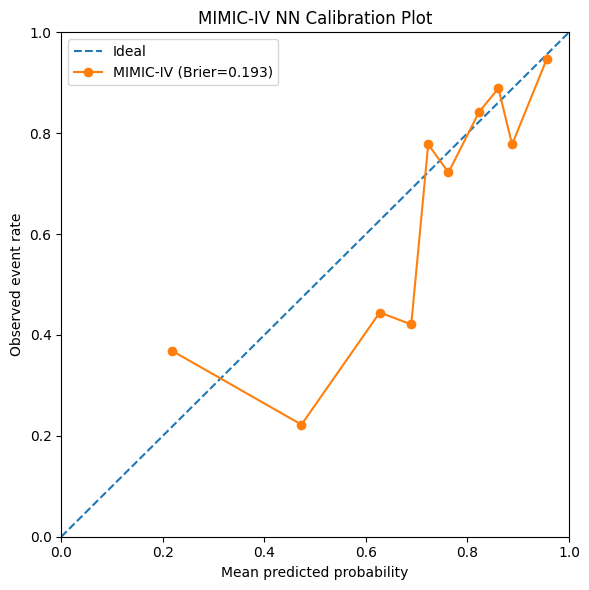

In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
# y_pred_prob = model.predict(X_test)[:, 1]

results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, probs_test),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"MIMIC-IV":probs_test}, y_test, "MIMIC-IV NN Calibration Plot")

In [29]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,184,0.641304,0.774782,0.186645,0.344551,0.94413


In [20]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
def missingness_table(df, treatment_col, threshold=30.0, exclude_cols=None, use_fisher_if_small=True):
    """
    Create a missingness summary table for one dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Pre-imputation dataframe.
    treatment_col : str
        Name of binary treatment column (0/1).
    threshold : float
        Percent missing threshold to flag, default 30.
    exclude_cols : list or None
        Columns to exclude from the missingness table.
    use_fisher_if_small : bool
        Use Fisher's exact test when expected cell counts are small.

    Returns
    -------
    pd.DataFrame
    """
    if exclude_cols is None:
        exclude_cols = []

    cols = [c for c in df.columns if c not in exclude_cols and c != treatment_col]

    rows = []

    treat = df[treatment_col]

    for col in cols:
        miss = df[col].isna().astype(int)

        n_total = len(df)
        n_missing = miss.sum()
        pct_missing = 100 * n_missing / n_total

        miss_ttm = miss[treat == 1]
        miss_nottm = miss[treat == 0]

        n_ttm = (treat == 1).sum()
        n_nottm = (treat == 0).sum()

        pct_missing_ttm = 100 * miss_ttm.mean() if n_ttm > 0 else np.nan
        pct_missing_nottm = 100 * miss_nottm.mean() if n_nottm > 0 else np.nan

        # contingency table:
        # rows = treatment group
        # cols = missing / not missing
        table = np.array([
            [miss_nottm.sum(), (treat == 0).sum() - miss_nottm.sum()],
            [miss_ttm.sum(), (treat == 1).sum() - miss_ttm.sum()]
        ])

        # default p-value
        pval = np.nan
        test_used = None

        try:
            chi2, p_chi, dof, expected = chi2_contingency(table, correction=False)

            if use_fisher_if_small and (expected < 5).any():
                _, pval = fisher_exact(table)
                test_used = "Fisher"
            else:
                pval = p_chi
                test_used = "Chi-square"
        except Exception:
            pval = np.nan
            test_used = "Failed"

        rows.append({
            "variable": col,
            "n_missing": int(n_missing),
            "pct_missing": pct_missing,
            "pct_missing_no_ttm": pct_missing_nottm,
            "pct_missing_ttm": pct_missing_ttm,
            "abs_diff_pct": abs(pct_missing_ttm - pct_missing_nottm),
            "p_value": pval,
            "test": test_used,
            "flag_gt_30pct": pct_missing > threshold
        })

    out = pd.DataFrame(rows).sort_values(
        ["flag_gt_30pct", "pct_missing"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return out
miss_eicu = missingness_table(
    df=pd.concat([X_train, X_test]),
    treatment_col="hypothermia",
    exclude_cols=["patient_id"]
)
def missingness_summary_stats(miss_df):
    return {
        "n_variables": len(miss_df),
        "n_gt_30pct": int(miss_df["flag_gt_30pct"].sum()),
        "max_pct_missing": miss_df["pct_missing"].max(),
        "median_pct_missing": miss_df["pct_missing"].median(),
        "n_p_lt_005": int((miss_df["p_value"] < 0.05).sum())
    }
print("eICU:", missingness_summary_stats(miss_eicu))

eICU: {'n_variables': 192, 'n_gt_30pct': 173, 'max_pct_missing': np.float64(100.0), 'median_pct_missing': np.float64(31.964285714285715), 'n_p_lt_005': 28}


In [455]:
miss_eicu = miss_eicu.rename(columns={
    "variable": "Variable",
    "n_missing": "Missing, n",
    "pct_missing": "Missing, %",
    "pct_missing_no_ttm": "Missing in No-TTM Group, %",
    "pct_missing_ttm": "Missing in TTM Group, %",
    "abs_diff_pct": "Absolute Difference, %",
    "p_value": "P Value",
    "test": "Statistical Test"
}).drop(columns=["flag_gt_30pct"])

In [456]:
miss_eicu.to_csv('table.csv')

In [457]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    # layers.Dense(64, activation='relu'),
    # layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


2026-04-03 14:39:49.223884: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [111]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=30, batch_size=8, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4594 - loss: 1.4577 - roc_auc: 0.5039 - val_accuracy: 0.5361 - val_loss: 0.7075 - val_roc_auc: 0.5738
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5544 - loss: 0.9497 - roc_auc: 0.5612 - val_accuracy: 0.6446 - val_loss: 0.6561 - val_roc_auc: 0.5952
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5941 - loss: 0.8571 - roc_auc: 0.5713 - val_accuracy: 0.6446 - val_loss: 0.6320 - val_roc_auc: 0.6157
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5851 - loss: 0.8764 - roc_auc: 0.5577 - val_accuracy: 0.6627 - val_loss: 0.6185 - val_roc_auc: 0.6485
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6174 - loss: 0.7366 - roc_auc: 0.5781 - val_accuracy: 0.6687 - val_loss: 0.6088 - val_roc_auc: 0.6655
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6167 - loss: 0.7284 - roc_auc: 0.5764 - val_accuracy: 0.6807 - val_loss: 0.6062 - val_roc_auc: 0.6753
Epoc

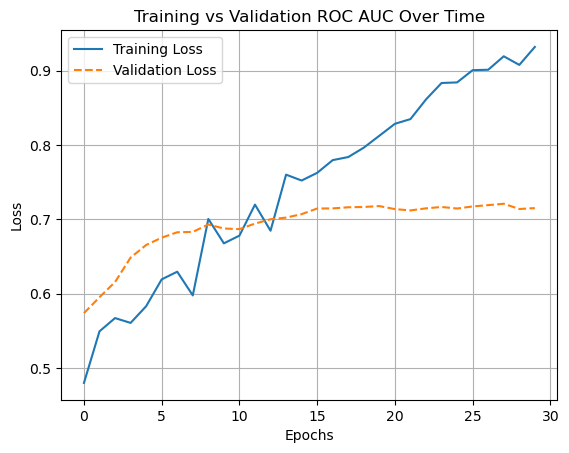

In [112]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

/home/mbranda1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 10/10 [00:03<00:00,  2.88it/s]


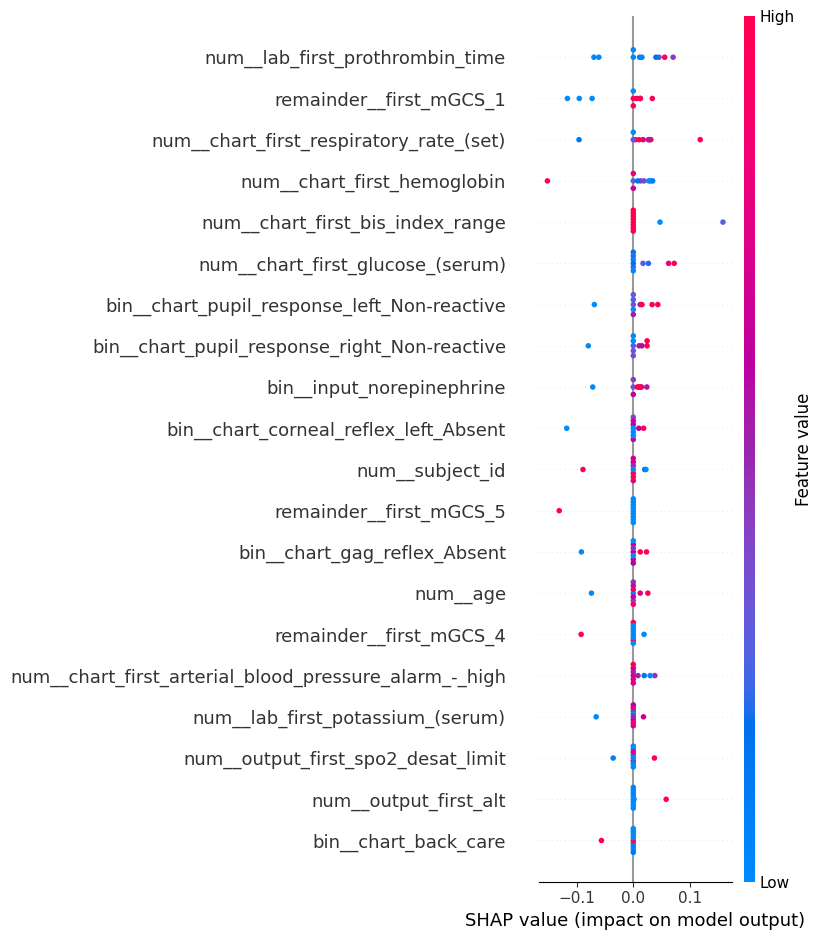

In [26]:
import shap
import numpy as np

# Use a small representative background set
X_background = X_test_transf[:100]
X_explain = X_test_transf[:10]

# shap needs a prediction function that outputs a 2D array
explainer = shap.KernelExplainer(model_torch.predict, X_background)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain)


In [27]:
import numpy as np
import pandas as pd

# 1. Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)  # shape: (n_features,)

# 2. Create a DataFrame for easy lookup and sorting
importance_df = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 3. Find the rank of a specific feature
feature_name = "bin__hypothermia"  # replace with your actual feature
rank = importance_df.index[importance_df['feature'] == feature_name].item() + 1
score = importance_df.loc[importance_df['feature'] == feature_name, 'mean_abs_shap'].item()

print(f"🔍 Feature '{feature_name}' is ranked #{rank} out of {X_explain.shape[1]} in importance with mean(|SHAP|) = {score:.4f}")


🔍 Feature 'bin__hypothermia' is ranked #93 out of 287 in importance with mean(|SHAP|) = 0.0008


In [477]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 298, but received input with shape (32, 294)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 294), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [116]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_pred_proba, n_bootstraps=1000, ci=95, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    bootstrapped_scores = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            # We need at least one positive and one negative sample
            continue
        score = roc_auc_score(y_true[indices], y_pred_proba[indices])
        bootstrapped_scores.append(score)
    
    sorted_scores = np.sort(bootstrapped_scores)
    lower_bound = np.percentile(sorted_scores, (100 - ci) / 2)
    upper_bound = np.percentile(sorted_scores, 100 - (100 - ci) / 2)
    
    return lower_bound, upper_bound, sorted_scores

# Example usage
# y_true = np.array([...])
# y_pred_proba = np.array([...])

ci_lower, ci_upper, auc_scores = bootstrap_auc_ci(y_test.to_numpy(), y_pred_probs)
print(f"95% CI for AUC: [{ci_lower:.3f}, {ci_upper:.3f}]")


95% CI for AUC: [0.635, 0.788]


In [560]:
myX = pd.concat([X_train_transf.reset_index().drop(columns='index'), X_test_transf.reset_index().drop(columns='index')])
myY = pd.concat([y_train.reset_index().drop(columns='index'), y_test.reset_index().drop(columns='index')])

Optimization terminated successfully.
         Current function value: 0.650136
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.649364
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.9439773802396303
p-value: 0.33125705601259703
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                  611
Model:                          Logit   Df Residuals:                      608
Method:                           MLE   Df Model:                            2
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                0.003636
Time:                        15:14:59   Log-Likelihood:                -397.23
converged:                       True   LL-Null:                       -398.68
Covariance Type:            nonrobust   LLR p-value:                    0.2347
                     

np.float64(0.33125705601259703)

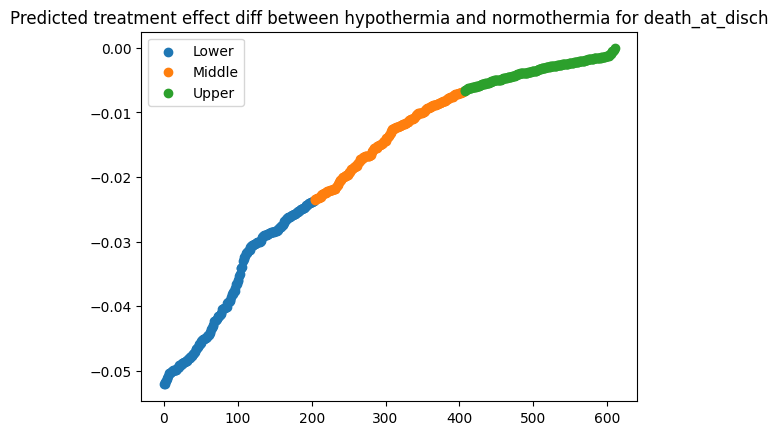

In [561]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = model_torch, \
                       aCategory = 'death_at_disch', aGroup = 'bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

In [404]:
getTreatmentEffectDiff(aX = X_train_transf.reset_index().drop(columns='index'), aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'death_at_disch', aGroup = 'keep__keep__bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

NameError: name 'model' is not defined